In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Upload and unzip the dataset

In [ ]:
DATA_ROOT = '/content/drive/MyDrive/assesment_Galaxeye/Galaxeye-BE_MLSys-TakeHome_Assignment-Tiles/be-mlsys-assignment-dataset'

import os
print(os.listdir(DATA_ROOT))

['eval_labels.csv', 'README.txt', 'eval_set', 'candidate_tiles']


Imports and setup

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)


Using device: cuda


Build datasets



In [ ]:
IMG_SIZE = 64  # keep tiles at their native resolution; no need to upscale to 224 since we're not using an ImageNet backbone

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),      # safe here: satellite tiles have no fixed "up"
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
])

eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
])

full_train_dataset = ImageFolder(f'{DATA_ROOT}/candidate_tiles', transform=train_transform)
CLASS_NAMES = full_train_dataset.classes
print('Classes:', CLASS_NAMES)

n_val = int(0.15 * len(full_train_dataset))
n_train = len(full_train_dataset) - n_val
train_ds, val_ds = random_split(full_train_dataset, [n_train, n_val],
                                 generator=torch.Generator().manual_seed(42))
# validation should NOT use train-time augmentation - swap its transform
val_ds.dataset.transform = eval_transform  # NOTE: this affects train_ds too since it's the same underlying dataset object; see next cell for the fix

print(f'Train: {n_train}  Val: {n_val}')

class EvalTileDataset(Dataset):
    def __init__(self, root, labels_csv, class_names, transform):
        self.root = root
        self.df = pd.read_csv(labels_csv)
        self.class_to_idx = {c: i for i, c in enumerate(class_names)}
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(f"{self.root}/{row['filename']}").convert('RGB')
        img = self.transform(img)
        label = self.class_to_idx[row['true_label']]
        return img, label

eval_dataset = EvalTileDataset(f'{DATA_ROOT}/eval_set', f'{DATA_ROOT}/eval_labels.csv',
                                CLASS_NAMES, eval_transform)
print('Eval set size:', len(eval_dataset))


Classes: ['AnnualCrop', 'Forest', 'Highway', 'Industrial', 'Residential', 'River', 'SeaLake']
Train: 893  Val: 157
Eval set size: 210


In [ ]:
train_dataset_aug = ImageFolder(f'{DATA_ROOT}/candidate_tiles', transform=train_transform)
train_dataset_plain = ImageFolder(f'{DATA_ROOT}/candidate_tiles', transform=eval_transform)

train_ds = torch.utils.data.Subset(train_dataset_aug, train_ds.indices)
val_ds = torch.utils.data.Subset(train_dataset_plain, val_ds.indices)

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


Define the CNN



In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )
        self.features = nn.Sequential(
            block(3, 32),    # 64x64 -> 32x32
            block(32, 64),   # 32x32 -> 16x16
            block(64, 128),  # 16x16 -> 8x8
            block(128, 256), # 8x8   -> 4x4
        )
        self.pool = nn.AdaptiveAvgPool2d(1)  # 4x4 -> 1x1, regardless of input size
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.classifier(x)

model = SmallCNN(num_classes=len(CLASS_NAMES)).to(device)
print(model)
print('Total params:', sum(p.numel() for p in model.parameters()))


SmallCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (3): Sequential(
      (0)

Train, with early stopping on validation accuracy

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
criterion = nn.CrossEntropyLoss()

EPOCHS = 40
PATIENCE = 8  # stop if val accuracy doesn't improve for this many epochs
best_val_acc = 0.0
epochs_without_improvement = 0
history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_ds)

    model.eval()
    val_loss, correct = 0.0, 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
    val_loss /= len(val_ds)
    val_acc = correct / len(val_ds)
    scheduler.step(val_acc)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1:2d}/{EPOCHS}  train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_acc={val_acc:.3f}')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), 'best_model.pt')
        print('  -> new best, checkpoint saved')
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f'No improvement for {PATIENCE} epochs, stopping early.')
            break

print(f'\nBest validation accuracy: {best_val_acc:.3f}')


Epoch  1/40  train_loss=1.3048  val_loss=2.0415  val_acc=0.280
  -> new best, checkpoint saved
Epoch  2/40  train_loss=0.9490  val_loss=1.4615  val_acc=0.395
  -> new best, checkpoint saved
Epoch  3/40  train_loss=0.8335  val_loss=1.1227  val_acc=0.561
  -> new best, checkpoint saved
Epoch  4/40  train_loss=0.7780  val_loss=1.2303  val_acc=0.580
  -> new best, checkpoint saved
Epoch  5/40  train_loss=0.7358  val_loss=1.2260  val_acc=0.650
  -> new best, checkpoint saved
Epoch  6/40  train_loss=0.6701  val_loss=0.8298  val_acc=0.694
  -> new best, checkpoint saved
Epoch  7/40  train_loss=0.6143  val_loss=1.4139  val_acc=0.567
Epoch  8/40  train_loss=0.6079  val_loss=1.0884  val_acc=0.662
Epoch  9/40  train_loss=0.6226  val_loss=0.7391  val_acc=0.726
  -> new best, checkpoint saved
Epoch 10/40  train_loss=0.5962  val_loss=0.7315  val_acc=0.713
Epoch 11/40  train_loss=0.5749  val_loss=0.8077  val_acc=0.688
Epoch 12/40  train_loss=0.5480  val_loss=0.5920  val_acc=0.771
  -> new best, check

Plot training curves (check for overfitting)

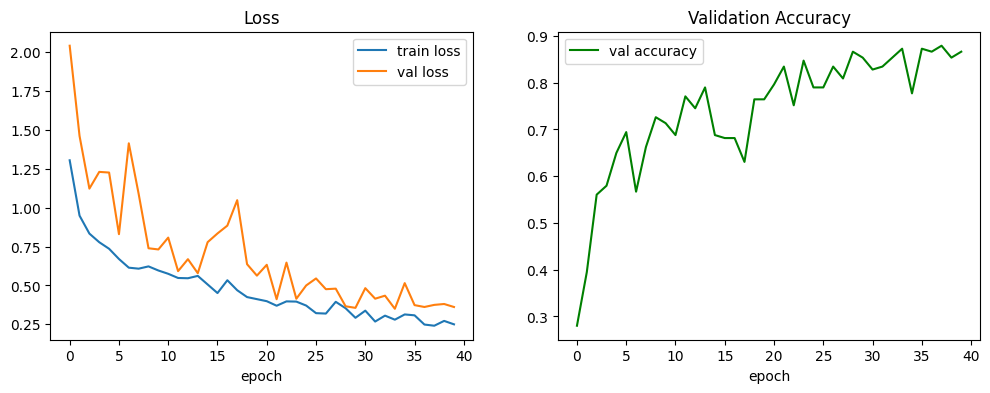

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train loss')
axes[0].plot(history['val_loss'], label='val loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()

axes[1].plot(history['val_acc'], label='val accuracy', color='green')
axes[1].set_title('Validation Accuracy'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.show()

# What to look for: if train_loss keeps dropping while val_loss starts rising,
# that's overfitting - the early stopping above should have caught it already.


Final, honest evaluation on eval_set

In [ ]:
model.load_state_dict(torch.load('best_model.pt'))
model.eval()

all_preds, all_labels, all_confidences = [], [], []
with torch.no_grad():
    for imgs, labels in eval_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        probs = F.softmax(outputs, dim=1)
        confs, preds = probs.max(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_confidences.extend(confs.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f'eval_set accuracy: {acc:.3f}\n')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

cm = confusion_matrix(all_labels, all_preds)
print('Confusion matrix (rows=true, cols=pred):')
print('Classes:', CLASS_NAMES)
print(cm)


eval_set accuracy: 0.895

              precision    recall  f1-score   support

  AnnualCrop       0.85      0.97      0.91        30
      Forest       1.00      0.97      0.98        30
     Highway       0.73      0.63      0.68        30
  Industrial       1.00      0.93      0.97        30
 Residential       1.00      0.97      0.98        30
       River       0.74      0.83      0.78        30
     SeaLake       0.97      0.97      0.97        30

    accuracy                           0.90       210
   macro avg       0.90      0.90      0.89       210
weighted avg       0.90      0.90      0.89       210

Confusion matrix (rows=true, cols=pred):
Classes: ['AnnualCrop', 'Forest', 'Highway', 'Industrial', 'Residential', 'River', 'SeaLake']
[[29  0  0  0  0  1  0]
 [ 0 29  0  0  0  0  1]
 [ 3  0 19  0  0  8  0]
 [ 0  0  2 28  0  0  0]
 [ 0  0  1  0 29  0  0]
 [ 1  0  4  0  0 25  0]
 [ 1  0  0  0  0  0 29]]


Save and download the trained model

In [ ]:
import json, shutil

torch.save(model.state_dict(), 'tile_cnn.pt')
with open('classes.json', 'w') as f:
    json.dump(CLASS_NAMES, f)

# Save into the same dataset folder in Drive (change this path if you'd rather use a different folder)
SAVE_DIR = '/content/drive/MyDrive/assesment_Galaxeye'
shutil.copy('tile_cnn.pt', f'{SAVE_DIR}/tile_cnn.pt')
shutil.copy('classes.json', f'{SAVE_DIR}/classes.json')

print(f'Saved to {SAVE_DIR}/tile_cnn.pt and {SAVE_DIR}/classes.json')

Saved to /content/drive/MyDrive/assesment_Galaxeye/tile_cnn.pt and /content/drive/MyDrive/assesment_Galaxeye/classes.json


In [ ]:
import torch, torchvision, PIL
print(torch.__version__)
print(torchvision.__version__)
print(PIL.__version__)

2.11.0+cu128
0.26.0+cu128
11.3.0
